# SAM

In [1]:
# !pip install segment-anything
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor
from segment_anything import sam_model_registry, SamPredictor
from segment_anything import SamAutomaticMaskGenerator


In [ ]:
#A LA TERMINAL
# pip install torch torchvision torchaudio numpy opencv-python matplotlib
# pip install git+https://github.com/facebookresearch/segment-anything.git

# # Download a model checkpoint
# wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth


In [2]:
sam_checkpoint = r"C:\Users\propietari\sintesisII\sam_vit_h_4b8939.pth"
model_type = "vit_h"  # Options: vit_h, vit_l, vit_b

# Load the model
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to("cuda" if torch.cuda.is_available() else "cpu")

# Create the predictor
predictor = SamPredictor(sam)

In [3]:

def segment_image(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask_generator = SamAutomaticMaskGenerator(sam)
    masks = mask_generator.generate(image)

    blank_canvas = np.ones_like(image) * 255  # White background
    blank_canvas_big = np.ones_like(image) * 255  # White background

    for mask in masks:
        segmentation = mask["segmentation"]
        # Generate a random color
        color = np.random.randint(0, 255, (1, 3), dtype=np.uint8)[0].tolist()
        # Convert binary mask to contours
        contours, _ = cv2.findContours(segmentation.astype(np.uint8), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        # Draw contours on the image
        cv2.drawContours(blank_canvas, contours, -1, color, 2)

    MIN_BABY_SIZE = 10000  
    filtered_masks = [m for m in masks if m['area'] > MIN_BABY_SIZE]  # Keep only large regions

    for mask in filtered_masks:
        segmentation = mask["segmentation"]
        color = np.random.randint(0, 255, (1, 3), dtype=np.uint8)[0].tolist()
        contours, _ = cv2.findContours(segmentation.astype(np.uint8), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(blank_canvas_big, contours, -1, color, 2)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Left: Original Image
    axes[0].imshow(image)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    # Right: Segmentation Contours
    axes[1].imshow(blank_canvas)
    axes[1].set_title("Segmentation Contours")
    axes[1].axis("off")

    axes[2].imshow(blank_canvas_big)
    axes[2].set_title("big segments")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    return image

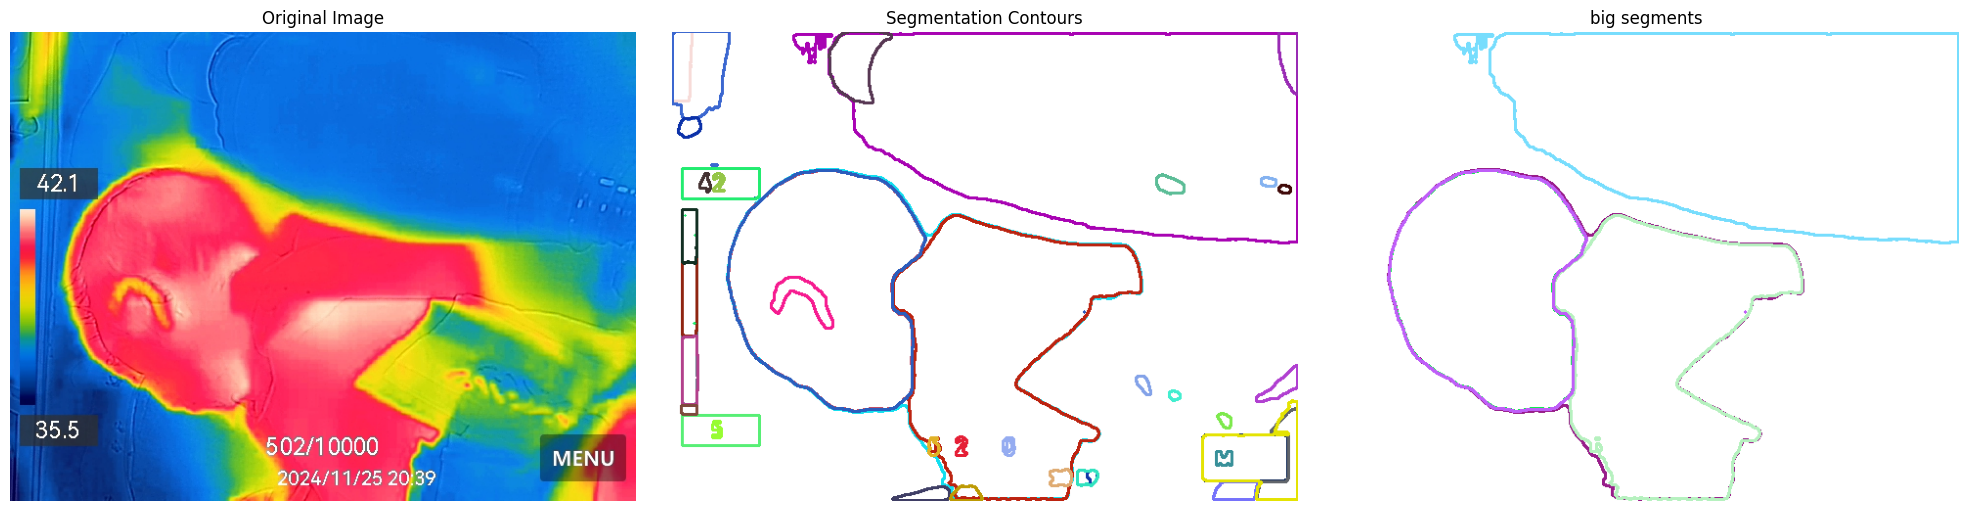

In [4]:
img = segment_image(r"C:\Users\propietari\Downloads\HM20241125203906.jpeg")


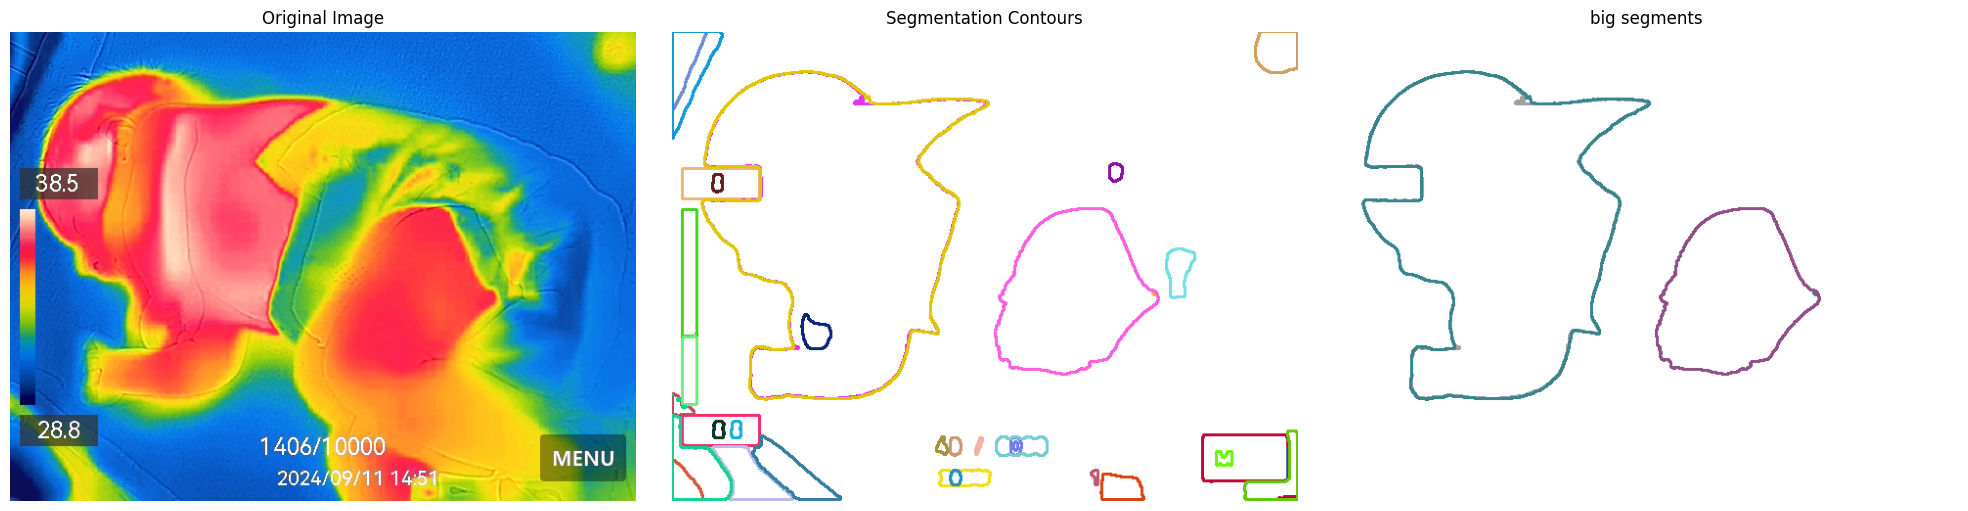

In [5]:
img = segment_image(r"C:\Users\propietari\Downloads\HM20240911145125.jpeg")

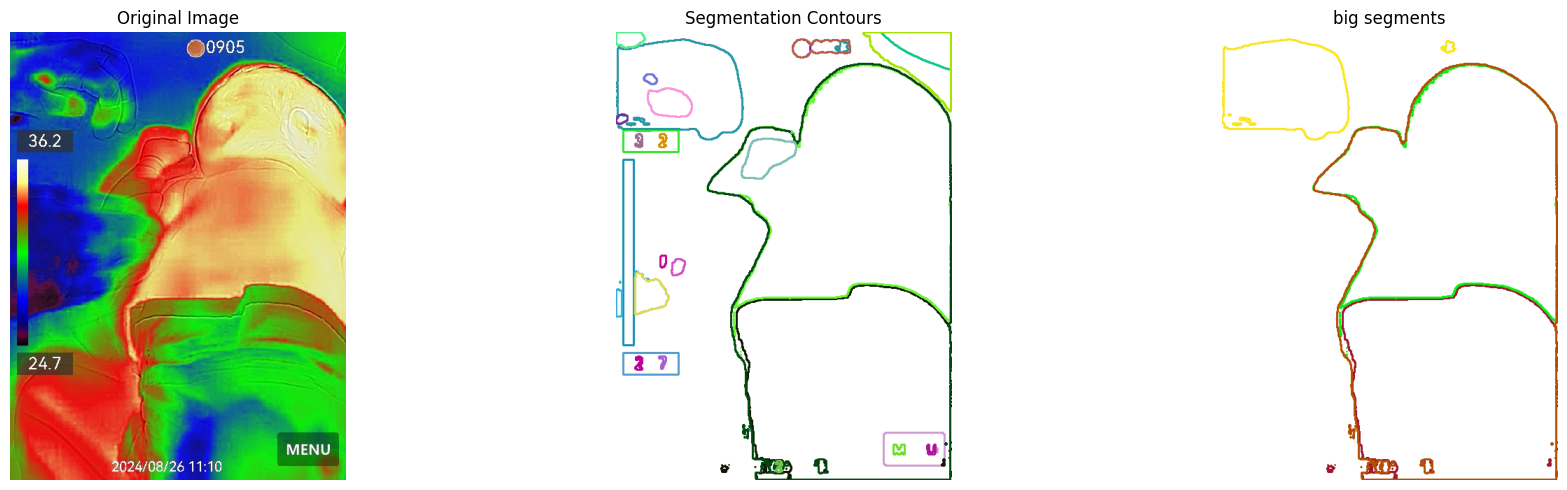

In [6]:
img = segment_image(r"C:\Users\propietari\Downloads\HM20240826111033.jpeg")


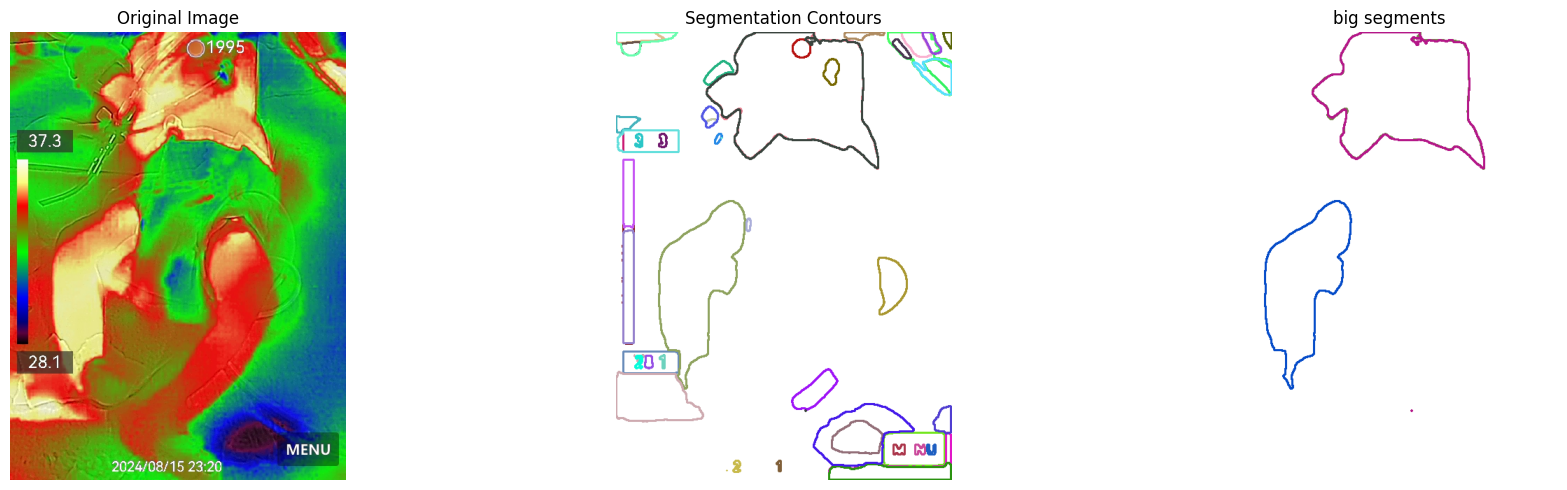

In [7]:
img = segment_image(r"C:\Users\propietari\Downloads\HM20240815232047.jpeg")


## Conclusions

The results obtained from the SAM (Segment Anything Model) are promising and show potential for further development. However, they require post-processing and filtering to become practically useful. The thermal images are often blurry, and the extracted contours do not consistently align with the different parts of the baby. Differentiating between the torso, hands, and feet is challenging, as these regions frequently lack clear and consistent shapes in the thermal image.

Additionally, the current implementation is time-consuming, which limits its usability for real-time or large-scale applications. To improve efficiency and scalability, implementing parallel processing or running the code on a GPU would be essential steps moving forward.

